In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('Islamabad_properties_outlier_missing.csv')

In [7]:
df.head()

,property_type,society,location,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_per_sqft,price_in_crore,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score
0,flat,DHA Phase 1 Apartments,DHA Phase 1,793.0,2,2,1,3,North-East,Moderately Old,23581.0,1.87,0,0,0,1,0,1,17
1,flat,G-15 Residency,G-15,870.0,2,2,3,3,East,New Property,21494.0,1.87,1,0,0,0,0,1,39
2,flat,Bahria Town Heights,Bahria Town,947.0,3,3,2,6,South,Under Construction,19430.0,1.84,0,1,0,0,0,2,8
3,flat,G-12 Homes,G-12,1322.0,3,4,3,9,North,Old Property,14070.0,1.86,0,0,0,1,0,0,17
4,flat,G-12 Plaza,G-12,356.0,1,1,1,1,West,Moderately Old,14326.0,0.51,1,0,0,0,0,0,27


In [9]:
train_df = df.drop(columns = ['price_per_sqft','society'])

In [11]:
train_df.head()

,property_type,location,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_in_crore,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score
0,flat,DHA Phase 1,793.0,2,2,1,3,North-East,Moderately Old,1.87,0,0,0,1,0,1,17
1,flat,G-15,870.0,2,2,3,3,East,New Property,1.87,1,0,0,0,0,1,39
2,flat,Bahria Town,947.0,3,3,2,6,South,Under Construction,1.84,0,1,0,0,0,2,8
3,flat,G-12,1322.0,3,4,3,9,North,Old Property,1.86,0,0,0,1,0,0,17
4,flat,G-12,356.0,1,1,1,1,West,Moderately Old,0.51,1,0,0,0,0,0,27


<Axes: xlabel='luxury_score'>

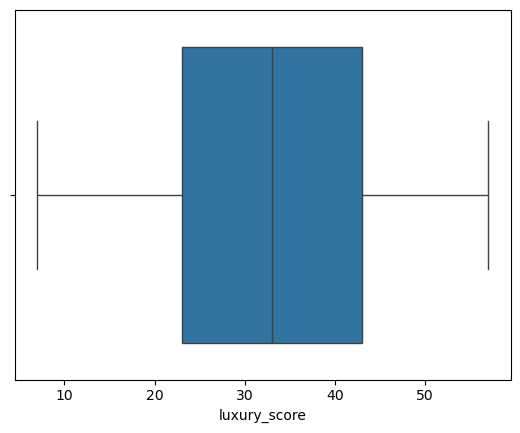

In [13]:
sns.boxplot(x = df['luxury_score'])

In [15]:
train_df['luxury_score'].describe()

count    4004.000000
mean       32.212787
std        12.191829
min         7.000000
25%        23.000000
50%        33.000000
75%        43.000000
max        57.000000
Name: luxury_score, dtype: float64

In [17]:
def categorize_luxury(score):
    if 0 <= score < 25:
        return 'Low' 
    elif 25<= score <43:
        return 'Medium'
    elif 43<= score < 60:
        return 'High'
    else:
        return None #undefined

In [19]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [21]:
train_df.sample(7)

,property_type,location,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_in_crore,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score,luxury_category
454,flat,F-11,1128.0,3,3,1,2,North-West,Under Construction,4.18,0,0,0,0,0,1,10,Low
3765,flat,Bahria Town,1595.0,4,5,0,5,North-West,Old Property,1.66,0,0,1,0,0,1,40,Medium
2700,flat,F-5,837.0,2,2,3,2,North-West,Relatively New,1.06,1,0,0,0,0,1,19,Low
3812,flat,Margalla Hills,895.0,2,2,3,8,North-West,Relatively New,1.83,1,0,0,0,0,1,24,Low
2925,flat,G-6,777.0,2,2,0,0,South,Under Construction,1.57,0,0,0,1,0,2,37,Medium
209,house,G-15,799.0,4,4,0,4,North,Moderately Old,2.00,0,1,0,0,0,1,51,High
226,house,Margalla Hills,799.0,5,3,1,5,South,Relatively New,1.96,0,0,1,0,0,1,53,High


<Axes: xlabel='floorNum'>

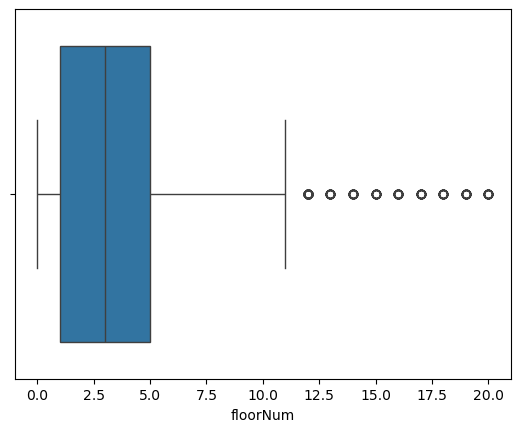

In [23]:
sns.boxplot(x = df['floorNum'])


In [25]:
def categorize_floor(floor):
    if 0 <= floor < 2 :
        return 'Low floor'
    elif 2 <= floor < 6:
        return 'Mid floor'
    elif 6<= floor < 22:
        return 'High floor'
    else :
        return None 

In [27]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [29]:
train_df.sample(5)

,property_type,location,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_in_crore,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score,luxury_category,floor_category
2126,flat,I-8,348.0,1,1,2,2,North-East,Under Construction,0.42,0,0,0,1,0,0,36,Medium,Mid floor
2102,flat,DHA Phase 1,622.0,2,2,0,10,North-West,Old Property,0.66,1,0,0,0,0,2,35,Medium,High floor
3319,house,G-15,2500.0,8,8,0,4,North-West,Under Construction,4.81,0,0,1,0,0,2,52,High,Mid floor
2516,flat,DHA Phase 3,1153.0,3,4,1,4,South,Moderately Old,2.10,0,0,0,0,0,0,28,Medium,Mid floor
1224,flat,E-7,1241.0,3,3,0,4,North,Under Construction,4.61,0,0,1,0,0,0,35,Medium,Mid floor


In [149]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [37]:
train_df.to_csv('Islamabad(reverse)_for_model_sel.csv',index = False)

In [31]:

train_df.head()

,property_type,location,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_in_crore,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,DHA Phase 1,793.0,2,2,1,3,North-East,Moderately Old,1.87,0,0,0,1,0,1,17,Low,Mid floor
1,flat,G-15,870.0,2,2,3,3,East,New Property,1.87,1,0,0,0,0,1,39,Medium,Mid floor
2,flat,Bahria Town,947.0,3,3,2,6,South,Under Construction,1.84,0,1,0,0,0,2,8,Low,High floor
3,flat,G-12,1322.0,3,4,3,9,North,Old Property,1.86,0,0,0,1,0,0,17,Low,High floor
4,flat,G-12,356.0,1,1,1,1,West,Moderately Old,0.51,1,0,0,0,0,0,27,Medium,Low floor


In [153]:
from sklearn.preprocessing import OrdinalEncoder
# ordinalencoder convert categorical data into int form

In [155]:

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

#splitting dataset into training and testing sets
X_label = data_label_encoded.drop('price_in_crore',axis = 1)
#X_label = data_label_encoded.drop(columns=['price_in_crore'])
y_label = data_label_encoded['price_in_crore']


[array(['flat', 'house'], dtype=object)]
[array(['Bahria Town', 'Chaklala', 'DHA Phase 1', 'DHA Phase 2',
       'DHA Phase 3', 'E-11', 'E-7', 'F-10', 'F-11', 'F-5', 'F-6', 'F-7',
       'F-8', 'G-10', 'G-11', 'G-12', 'G-13', 'G-14', 'G-15', 'G-6',
       'G-9', 'Gulzar-e-Quaid', 'I-8', 'Margalla Hills', 'Rawalp',
       'Sadiqabad'], dtype=object)]
[array(['East', 'North', 'North-East', 'North-West', 'South', 'South-East',
       'South-West', 'West'], dtype=object)]
[array(['Just Completed', 'Moderately Old', 'New Property', 'Old Property',
       'Relatively New', 'Under Construction'], dtype=object)]
[array(['High', 'Low', 'Medium'], dtype=object)]
[array(['High floor', 'Low floor', 'Mid floor'], dtype=object)]


In [157]:
X_label

,property_type,location,area,bedRoom,bathroom,balcony,facing,agePossession,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_category,floor_category
0,0.0,2.0,793.0,2,2,1,2.0,1.0,0,0,0,1,0,1,1.0,2.0
1,0.0,18.0,870.0,2,2,3,0.0,2.0,1,0,0,0,0,1,2.0,2.0
2,0.0,0.0,947.0,3,3,2,4.0,5.0,0,1,0,0,0,2,1.0,0.0
3,0.0,15.0,1322.0,3,4,3,1.0,3.0,0,0,0,1,0,0,1.0,0.0
4,0.0,15.0,356.0,1,1,1,7.0,1.0,1,0,0,0,0,0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,0.0,2.0,935.0,3,3,1,7.0,0.0,0,1,0,0,0,2,2.0,1.0
4000,0.0,11.0,1196.0,3,3,0,7.0,2.0,0,0,1,0,0,1,2.0,0.0
4001,1.0,13.0,3627.0,16,17,0,5.0,4.0,0,0,0,0,1,0,2.0,2.0
4002,0.0,18.0,1480.0,4,4,3,4.0,4.0,0,0,1,0,0,2,0.0,2.0


In [159]:
y_label

0       1.87
1       1.87
2       1.84
3       1.86
4       0.51
        ... 
3999    1.85
4000    2.46
4001    8.89
4002    1.88
4003    1.11
Name: price_in_crore, Length: 4004, dtype: float64

<Axes: >

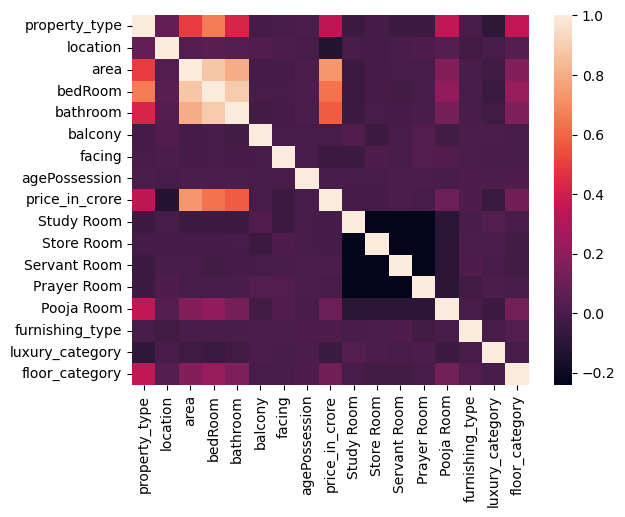

In [161]:
#correlation analysis
# linear relation r dependence between colom

sns.heatmap(data_label_encoded.corr())

In [162]:
fi_df1 = data_label_encoded.corr()['price_in_crore'].iloc[1:].to_frame().reset_index().rename(columns = {'index':'feature','price_in_crore':'corr_coeff'})

In [163]:
fi_df1

,feature,corr_coeff
0,location,-0.119638
1,area,0.730224
2,bedRoom,0.634334
3,bathroom,0.577153
4,balcony,-0.004383
5,facing,-0.039096
6,agePossession,-0.003401
7,price_in_crore,1.000000
8,Study Room,-0.015186
9,Store Room,-0.013055


In [164]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)


In [168]:
fi_df2

,feature,rf_importance
2,area,0.604521
1,location,0.286217
6,facing,0.016524
7,agePossession,0.013578
3,bedRoom,0.011711
0,property_type,0.009981
4,bathroom,0.009345
5,balcony,0.009139
14,luxury_category,0.007673
13,furnishing_type,0.007629


In [169]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
2,area,0.624029
1,location,0.351674
3,bedRoom,0.007584
0,property_type,0.005891
12,Pooja Room,0.001911
14,luxury_category,0.001877
6,facing,0.001724
9,Store Room,0.001543
4,bathroom,0.000992
13,furnishing_type,0.000905


In [170]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
2,area,1.454164
1,location,0.661227
0,property_type,0.008840
4,bathroom,0.003228
3,bedRoom,0.002546
14,luxury_category,0.001885
10,Servant Room,0.001560
13,furnishing_type,0.001221
5,balcony,0.000945
12,Pooja Room,0.000144


In [171]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
2,area,1.128278
10,Servant Room,0.011347
8,Study Room,0.009685
13,furnishing_type,0.008212
5,balcony,0.002185
0,property_type,-0.000000
3,bedRoom,0.000000
4,bathroom,0.000000
9,Store Room,-0.000000
11,Prayer Room,0.000000


In [172]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
2,area,0.604664
1,location,0.285282
6,facing,0.015916
7,agePossession,0.014130
3,bedRoom,0.012726
0,property_type,0.009614
4,bathroom,0.009490
14,luxury_category,0.008810
5,balcony,0.008766
13,furnishing_type,0.007711


In [173]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
2,area,1.153235
10,Servant Room,0.038971
8,Study Room,0.037781
11,Prayer Room,0.027883
3,bedRoom,0.022043
9,Store Room,0.020413
13,furnishing_type,0.018432
5,balcony,0.011916
12,Pooja Room,-0.003895
15,floor_category,-0.007076


In [174]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').set_index('feature')

In [175]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
location,-0.119638,0.286217,0.351674,0.661227,-0.205115,0.285282,-0.214356
area,0.730224,0.604521,0.624029,1.454164,1.128278,0.604664,1.153235
bedRoom,0.634334,0.011711,0.007584,0.002546,0.000000,0.012726,0.022043
bathroom,0.577153,0.009345,0.000992,0.003228,0.000000,0.009490,-0.028045
balcony,-0.004383,0.009139,0.000191,0.000945,0.002185,0.008766,0.011916
facing,-0.039096,0.016524,0.001724,-0.001967,-0.032918,0.015916,-0.042884
agePossession,-0.003401,0.013578,0.000796,-0.002192,-0.004239,0.014130,-0.014552
Study Room,-0.015186,0.004160,0.000884,-0.000303,0.009685,0.003809,0.037781
Store Room,-0.013055,0.003570,0.001543,-0.001397,-0.000000,0.003570,0.020413


In [176]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [177]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
area               0.633676
location           0.310692
facing             0.008392
bedRoom            0.008377
agePossession      0.006937
bathroom           0.005385
luxury_category    0.004856
balcony            0.004680
furnishing_type    0.004245
floor_category     0.002948
Servant Room       0.002258
Study Room         0.002198
Store Room         0.002026
Pooja Room         0.001835
Prayer Room        0.001495
dtype: float64

In [179]:
X_label

,property_type,location,area,bedRoom,bathroom,balcony,facing,agePossession,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_category,floor_category
0,0.0,2.0,793.0,2,2,1,2.0,1.0,0,0,0,1,0,1,1.0,2.0
1,0.0,18.0,870.0,2,2,3,0.0,2.0,1,0,0,0,0,1,2.0,2.0
2,0.0,0.0,947.0,3,3,2,4.0,5.0,0,1,0,0,0,2,1.0,0.0
3,0.0,15.0,1322.0,3,4,3,1.0,3.0,0,0,0,1,0,0,1.0,0.0
4,0.0,15.0,356.0,1,1,1,7.0,1.0,1,0,0,0,0,0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,0.0,2.0,935.0,3,3,1,7.0,0.0,0,1,0,0,0,2,2.0,1.0
4000,0.0,11.0,1196.0,3,3,0,7.0,2.0,0,0,1,0,0,1,2.0,0.0
4001,1.0,13.0,3627.0,16,17,0,5.0,4.0,0,0,0,0,1,0,2.0,2.0
4002,0.0,18.0,1480.0,4,4,3,4.0,4.0,0,0,1,0,0,2,0.0,2.0


In [181]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [183]:

scores.mean()

0.8302531800920641

In [184]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['Pooja Room', 'Study Room', 'Prayer Room','Servant Room','Store Room']), y_label, cv=5, scoring='r2')

In [185]:

scores.mean()

0.8327637650018381

In [187]:
export_df = X_label.drop(columns=['Pooja Room', 'Study Room', 'Prayer Room'])
export_df['price'] = y_label

In [188]:
export_df.to_csv('Islamabad_post_feature_selection.csv', index=False)

In [189]:
export_df

,property_type,location,area,bedRoom,bathroom,balcony,facing,agePossession,Store Room,Servant Room,furnishing_type,luxury_category,floor_category,price
0,0.0,2.0,793.0,2,2,1,2.0,1.0,0,0,1,1.0,2.0,1.87
1,0.0,18.0,870.0,2,2,3,0.0,2.0,0,0,1,2.0,2.0,1.87
2,0.0,0.0,947.0,3,3,2,4.0,5.0,1,0,2,1.0,0.0,1.84
3,0.0,15.0,1322.0,3,4,3,1.0,3.0,0,0,0,1.0,0.0,1.86
4,0.0,15.0,356.0,1,1,1,7.0,1.0,0,0,0,2.0,1.0,0.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,0.0,2.0,935.0,3,3,1,7.0,0.0,1,0,2,2.0,1.0,1.85
4000,0.0,11.0,1196.0,3,3,0,7.0,2.0,0,1,1,2.0,0.0,2.46
4001,1.0,13.0,3627.0,16,17,0,5.0,4.0,0,0,0,2.0,2.0,8.89
4002,0.0,18.0,1480.0,4,4,3,4.0,4.0,0,1,2,0.0,2.0,1.88
